In [1]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm

from css_utility_working import *
import css_utility_rnakato as crb

In [2]:
# str1 = "up100000_down90000_stride2"
# str2 = "high_exp_vs_RPKM_log3_k4"
# preddir = f"predict_logscale_train30000_dev6000_notomitO/{str1}/{str2}/"
preddir = "./Revision_code/high_exp_vs_RPKM_log3_k4"

attnfile = f'{preddir}/atten.npy'
predfile = f'{preddir}/pred_results.npy'
devfile = f'{preddir}/dev.tsv'
# devfile = f"finetune_data_logscale_train30000_dev6000_notomitO//{str1}/{str2}/dev.tsv"

dev_mat = crb.dev_conv_rnakato(devfile, stride=1)
attention_mat_raw = np.load(attnfile)
attention_mat, token_lengths = crb.truncate_attention_by_token_length(dev_mat, attention_mat_raw)
prediction_mat = np.load(predfile)

attention_mat[:5]

array([[0.00332439, 0.00305368, 0.00341072, ..., 0.        , 0.        ,
        0.        ],
       [0.00666451, 0.00710797, 0.00700617, ..., 0.        , 0.        ,
        0.        ],
       [0.00252935, 0.00209669, 0.00196701, ..., 0.        , 0.        ,
        0.        ],
       [0.00389804, 0.00427901, 0.00459476, ..., 0.        , 0.        ,
        0.        ],
       [0.01793183, 0.01360548, 0.01303046, ..., 0.        , 0.        ,
        0.        ]], shape=(5, 512))

In [3]:
TP_idx, TN_idx, FP_idx, FN_idx = crb.get_confusion_index(prediction_path=predfile, dev_path=devfile)
print(TP_idx[:5])
print(TN_idx[:5])
print(FP_idx[:5])
print(FN_idx[:5])

[3 5 6 8 9]
[ 0  4  7 10 11]
[ 1  2 12 14 15]
[20 26 30 38 41]


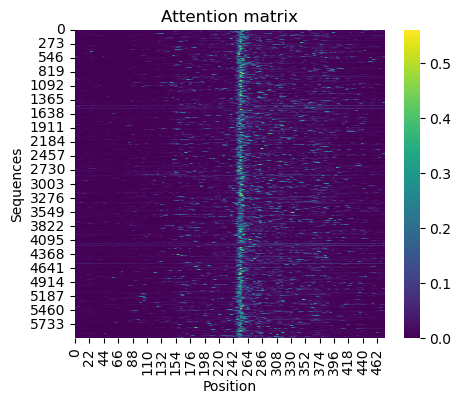

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
sns.heatmap(attention_mat[:,:474], cmap="viridis")
plt.title("Attention matrix")
plt.xlabel("Position")
plt.ylabel("Sequences");
# plt.savefig("fig_temp/AttentionMatrix.pdf")

Figure 4(a)


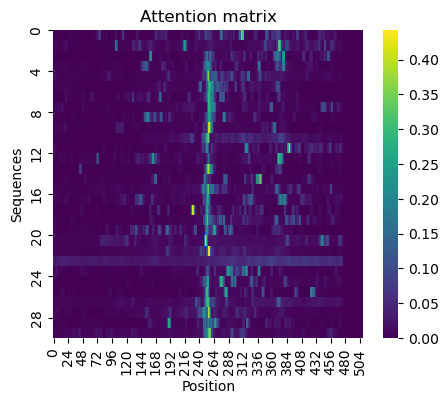

In [5]:
plt.figure(figsize=(5, 4))

ax = sns.heatmap(attention_mat[:30, :510], cmap="viridis")

# Set ticks every 5 positions (adjust as you like)
# ax.set_xticks(range(0, 510, 5))
# ax.set_xticklabels(range(0, 510, 5))

ax.set_yticks(range(0, 31, 4))
ax.set_yticklabels(range(0, 31, 4))

plt.title("Attention matrix")
plt.xlabel("Position")
plt.ylabel("Sequences")

print("Figure 4(a)")
# plt.savefig("fig_temp/AttentionMatrix.pdf")

Figure 4(b)


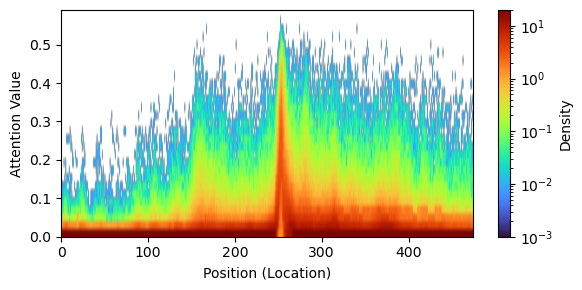

In [6]:
bins = np.linspace(0, 1, 50)
hist2d = np.array([
    np.histogram(attention_mat[:, i], bins=bins, density=True)[0]
    for i in range(attention_mat.shape[1])]).T

plt.figure(figsize=(6, 3))
plt.imshow(hist2d, aspect='auto', cmap='turbo', origin='lower', extent=[0, attention_mat.shape[1], bins[0], bins[-1]], 
          norm=LogNorm(vmin=1e-3, vmax=20) )
plt.colorbar(label='Density')
plt.xlim(0, 474)
plt.ylim(0, 0.59)
plt.xlabel("Position (Location)")
plt.ylabel("Attention Value")
plt.tight_layout()
print("Figure 4(b)")
# plt.savefig("fig_temp/AttentionMatrixDist_logscale.pdf")

In [7]:
base_dir = "./Revision_code/motif/motif_logscale_train30000_dev6000_notomitO/up100000_down90000_stride2"

# directories you listed
dirs = [
    "high_exp_vs_not_exp_k4",
    "high_exp_vs_RPKM_log1_k4",
    "high_exp_vs_RPKM_log2_k4",
    "high_exp_vs_RPKM_log3_k4",
    "high_exp_vs_RPKM_log4_k4",
    "high_exp_vs_RPKM_log5_k4",
]

motifs_dict = {}

for d in dirs:
    csv_path = os.path.join(base_dir, d, "init_df.csv")
    df = pd.read_csv(csv_path)

    # take the first column (motif)
    motifs = df.iloc[:, 0].tolist()   # same as df["motif"].tolist() if column name is exactly 'motif'

    motifs_dict[d] = motifs

# check result
for k, v in motifs_dict.items():
    print(k, len(v))
    # print(v[:5])  # if you want a preview


high_exp_vs_not_exp_k4 2177
high_exp_vs_RPKM_log1_k4 1692
high_exp_vs_RPKM_log2_k4 1226
high_exp_vs_RPKM_log3_k4 898
high_exp_vs_RPKM_log4_k4 354
high_exp_vs_RPKM_log5_k4 58


Figure 4(c)-1


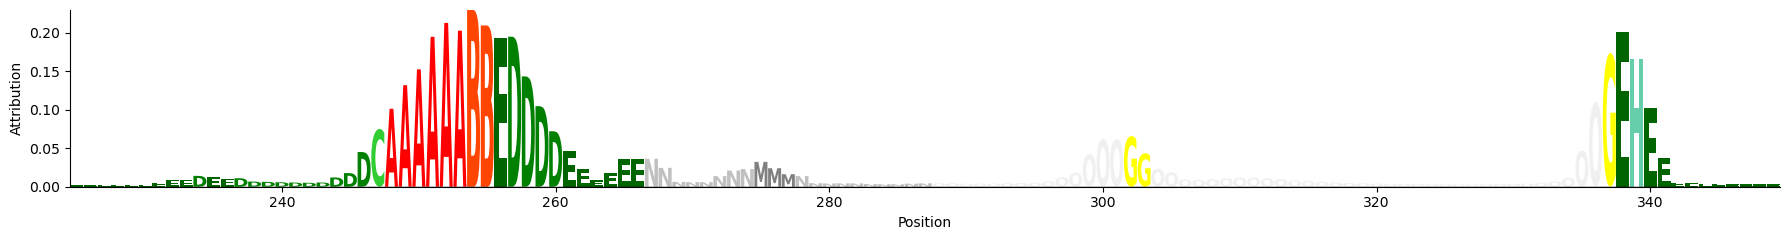

In [8]:
print("Figure 4(c)-1")
for id in TP_idx[:1]:
    crb.logo_from_dev_attention(dev_mat, attention_mat, id, f"figs/{id}_adj.pdf", xsize=18, ysize=2.5,range_=range(225,350))

Figure 4(c)-2


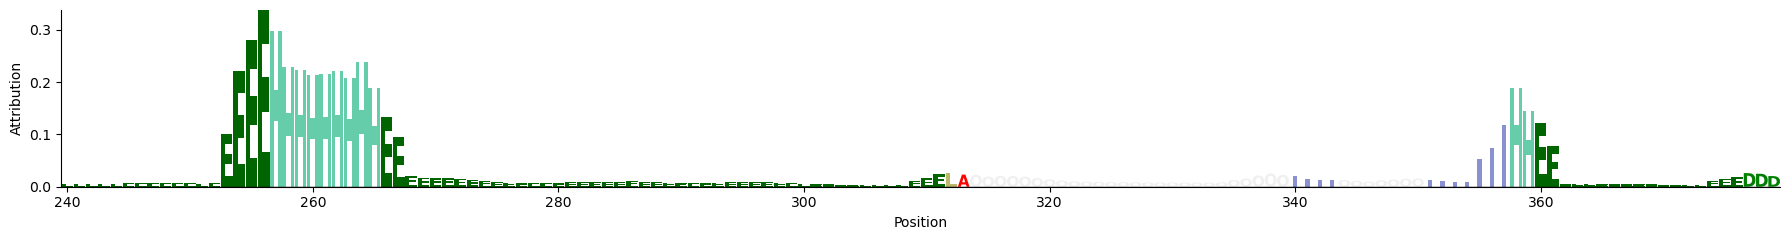

In [9]:
print("Figure 4(c)-2")
for id in TN_idx[2:3]:
    crb.logo_from_dev_attention(dev_mat, attention_mat, id, f"figs/{id}_adj.pdf", xsize=18, ysize=2.5,range_=range(240,380))

In [10]:
def motif_color_graph(motif_dic, figsize=(19, 10), save_path="./Revision_code/motif"):
    """
    motif_dic is the dictionary acquired by motif_cp1_ext
    """
    data = motif_dic
    fig, ax = plt.subplots(figsize=figsize)

    def get_rgb(letter):
        if letter in state_col_255_dict:
            r, g, b = state_col_255_dict[letter]
            return (r / 255, g / 255, b / 255)
        return (0, 0, 0)  # Default black color

    # Compute counts for each letter per task
    letter_counts_per_task = {}
    for task, strings in data.items():
        counts = {}
        for s in strings:
            for letter in s:
                counts[letter] = counts.get(letter, 0) + 1
        letter_counts_per_task[task] = counts

    # Unique legend tracking
    added_to_legend = set()

    # Draw the stacked bar
    for i, (task, letter_counts) in enumerate(letter_counts_per_task.items()):
        bottom = 0
        for letter, count in letter_counts.items():
            label_text = f"{css_dict[letter]} ({letter})"
            if label_text not in added_to_legend:
                ax.bar(i, count, bottom=bottom, color=get_rgb(letter), label=label_text)
                added_to_legend.add(label_text)
            else:
                ax.bar(i, count, bottom=bottom, color=get_rgb(letter))
            bottom += count

    # Reordering the legend items alphabetically
    handles, labels = ax.get_legend_handles_labels()
    # Extract the letter from each label, use it for sorting
    sorted_legend_items = sorted(zip(handles, labels), key=lambda x: x[1].split()[-1])  # assuming the letter is the last element in the label string
    sorted_handles, sorted_labels = zip(*sorted_legend_items)

    ax.legend(sorted_handles, sorted_labels, loc='upper left',bbox_to_anchor=(1, 1), fontsize=8)

    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.keys(), rotation=45, ha='right', fontsize=8)
    ax.set_title('State composition of the motifs in the promoters', fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.75)
    
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    
    plt.show()

Figure 4(d)


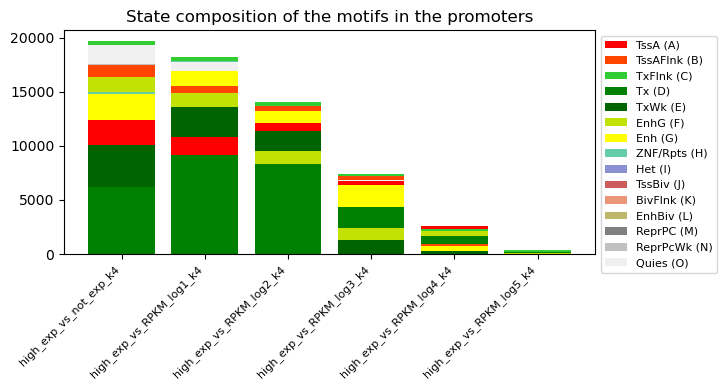

In [11]:
print("Figure 4(d)")
motif_color_graph(motifs_dict, figsize=(8, 4), save_path="./Revision_code/motif/fig4_c_test.pdf")